In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader as pdr
import datetime 
import matplotlib.pyplot as plt

In [2]:
all_return = pd.read_csv('allreturn.txt')
eff_fro_port = pd.read_csv('EfficientFrontierPortfolio.txt')
ETF = pd.read_csv('ETF.txt')
Fama_French = pd.read_csv('Fama-French')
MSFT = pd.read_csv('Microsoft_prices.txt')

### Univariate Investment Risk and Return

In [3]:
MSFT.head()

,Date,Open,High,Low,Close,Volume,Adjusted
0,2000-01-03,88.777,89.722,84.712,58.28125,53228400,38.527809
1,2000-01-04,85.893,88.588,84.901,56.31250,54119000,37.226345
2,2000-01-05,84.050,88.021,82.726,56.90625,64059600,37.618851
3,2000-01-06,84.853,86.130,81.970,55.00000,54976600,36.358688
4,2000-01-07,82.159,84.901,81.166,55.71875,62013600,36.833828


In [4]:
# Calculate daily return
MSFT['Return'] = MSFT['Adjusted'].pct_change()

<AxesSubplot:>

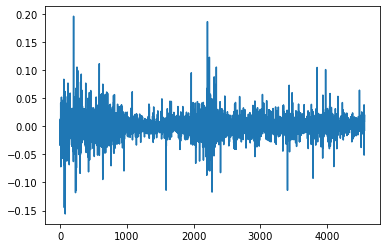

In [5]:
MSFT['Return'].plot()

In [6]:
# Calculate mean daily return
mean_daily_return = np.mean(MSFT['Return'])
mean_daily_return

0.00037777546435757725

In [7]:
# The investors are only interested in the annual return. Thus, we calculate annual return from daily return using the formula 
# ((1+daily_return)^252) - 1
annual_return = ((1+mean_daily_return)**252) - 1
annual_return

0.09985839482858783

In [8]:
# In the 18 years span, from 2000 to 2018, Microsoft stock earns investor an average 10% return per year

In [9]:
# Investors are also interested to learn about how volatily the stock is
# We can find it using the standard deviation

In [10]:
daily_std = np.std(MSFT['Return'])
daily_std

0.019341100408708328

In [11]:
# Similar to the return, annual standard deviation is what we are looking for
# Annual std = n^0.5 * daily_std. Since there are 252 trading days, so n = 252 in this case
annual_std = daily_std * np.sqrt(252)
annual_std

0.3070304505826317

In [12]:
from scipy.stats import skew
skew(MSFT['Return'].dropna())

0.21935459193067852

In [13]:
# Negative skewness suggest the data is not normal. Skew to the left

In [14]:
from scipy.stats import kurtosis
kurtosis(MSFT['Return'].dropna())

10.31457261802553

In [15]:
# The kurtosis function return a excess kurtosis, to find a true kurtosis value, add 3 to 4.3 = 7.3
# The normal distribution kurtosis is 3, clearly the stock is not normal
# We will perform one more test called Shapiro-Wilk to confirm it is not normal

In [16]:
from scipy.stats import shapiro
daily_return = mean_daily_return.dropna()
shapiro_results = shapiro(daily_return)
print("Shapiro results:", shapiro_results)

# Extract the p-value from the shapiro_results
p_value = shapiro_results[1]
print("P-value: ", p_value)


AttributeError: 'float' object has no attribute 'dropna'

In [ ]:
# Since p-value is smaller than 0.05, we can strongly confirm that the stock is not normally distributed

### CAPM

In [17]:
Fama_French.head()

,Date,Portfolio,Market_Excess,SMB,HML,RMW,CMA,RF
0,2013-01-03,-0.005066,-0.0014,0.0014,0.0004,0.0020,0.0023,0.0
1,2013-01-04,0.004024,0.0055,0.0019,0.0043,-0.0037,0.0027,0.0
2,2013-01-07,0.004421,-0.0031,-0.0009,-0.0037,-0.0013,-0.0012,0.0
3,2013-01-08,-0.004659,-0.0027,0.0004,-0.0007,-0.0012,0.0009,0.0
4,2013-01-09,0.004636,0.0034,0.0024,-0.0041,-0.0007,-0.0015,0.0


In [18]:
Fama_French['Port_Excess'] = Fama_French['Portfolio'] - Fama_French['RF']

In [19]:
CumulativeReturns = ((1+Fama_French[['Portfolio','Port_Excess']]).cumprod()-1)

<AxesSubplot:>

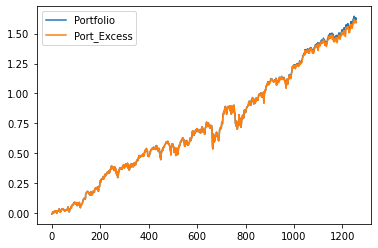

In [20]:
CumulativeReturns.plot()

### There are 2 ways of calculating Beta: Using covariance and CAPM

#### Using covariance

In [21]:
## Beta = Cov / Var(Benchmark Index)
cov_matrix = Fama_French[['Port_Excess','Market_Excess']].cov()

In [22]:
cov_coef = cov_matrix.iloc[0,1]

In [23]:
cov_coef

5.726126338154974e-05

#### Using CAPM

In [24]:
# Import statsmodels.formula.api
import statsmodels.formula.api as smf

In [25]:
CAPM_model = smf.ols(formula='Port_Excess~Market_Excess',data=Fama_French)

In [26]:
CAPM_fit = CAPM_model.fit()

In [30]:
CAPM = CAPM_fit.summary()
print(CAPM)

                            OLS Regression Results                            
Dep. Variable:            Port_Excess   R-squared:                       0.794
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     4854.
Date:                Tue, 08 Mar 2022   Prob (F-statistic):               0.00
Time:                        08:40:39   Log-Likelihood:                 5226.5
No. Observations:                1258   AIC:                        -1.045e+04
Df Residuals:                    1256   BIC:                        -1.044e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0002      0.000      2.009

In [31]:
# Extract beta
beta = CAPM_fit.params['Market_Excess']
beta

0.9737755165745478

### The Fama-French 3 factor Model

In [33]:
import statsmodels.formula.api as smf
Fama_3 = smf.ols(formula='Port_Excess~Market_Excess + SMB + HML', data=Fama_French)

In [34]:
Fama3_fit = Fama_3.fit()

In [35]:
Fama3_sum = Fama3_fit.summary()
print(Fama3_sum)

                            OLS Regression Results                            
Dep. Variable:            Port_Excess   R-squared:                       0.820
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     1902.
Date:                Tue, 08 Mar 2022   Prob (F-statistic):               0.00
Time:                        08:48:23   Log-Likelihood:                 5309.4
No. Observations:                1258   AIC:                        -1.061e+04
Df Residuals:                    1254   BIC:                        -1.059e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0002      0.000      1.820

In [36]:
# We can see that the R-squared for the 3 factor model is greater than the CAPM Model 

In [38]:
portfolio_alpha = Fama3_fit.params['Intercept']
print(portfolio_alpha)

0.0001832666520318342


In [39]:
# Annualize your portfolio alpha
portfolio_alpha_annualized = ((1+portfolio_alpha)**252)-1
print(portfolio_alpha_annualized)

0.04726181730280854


### The 5 factor model

In [42]:
# Define the regression formula
FamaFrench5_model = smf.ols(formula='Port_Excess ~ Market_Excess + SMB + HML + RMW + CMA', data=Fama_French)

# Fit the regression
FamaFrench5_fit = FamaFrench5_model.fit()

In [44]:
Fama5_sum = FamaFrench5_fit.summary()
print(Fama5_sum)

                            OLS Regression Results                            
Dep. Variable:            Port_Excess   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     1289.
Date:                Tue, 08 Mar 2022   Prob (F-statistic):               0.00
Time:                        08:52:38   Log-Likelihood:                 5373.9
No. Observations:                1258   AIC:                        -1.074e+04
Df Residuals:                    1252   BIC:                        -1.070e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0002   9.58e-05      1.819